# Espacios vectoriales y transformaciones lineales aplicados a Deep Learning

**Maestría**: Inteligencia Artificial Aplicada  
**Asignatura**: Aprendizaje Profundo  
**Profesor**: Jefferson Rodríguez

## Propósito

En este notebook estudiaremos dos ideas fundamentales para comprender las redes neuronales:

1. **Espacios vectoriales:** permiten describir datos, características, parámetros y representaciones aprendidas como objetos matemáticos.
2. **Transformaciones lineales:** permiten comprender cómo una capa neuronal transforma una representación mediante operaciones del tipo $(W\mathbf{x}+\mathbf{b})$.

> **Idea central:** una red neuronal puede verse como una sucesión de transformaciones de representaciones. Las capas lineales transforman espacios y las funciones de activación introducen la no linealidad necesaria para aprender relaciones complejas.


## 1. ¿Por qué necesitamos espacios vectoriales en Deep Learning?

Nos permiten transformar información compleja (imágenes, texto, videos, etc) en números y operaciones matemáticas que las computadoras podrán entender y aprender patrones de ello. Los computadores no entienden palabras, o imágenes por si solas, se hace necesario representarlas de forma numérica.  

Un dato puede representarse mediante un vector de características:
$$
\mathbf{x} =
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_d
\end{bmatrix}
\in \mathbb{R}^d
$$


Ejemplos:

- Una observación tabular puede representarse como un vector en $\mathbb{R}^d$.
- Una imagen de tamaño (28,28) puede aplanarse como un vector de 784 componentes.
- Un embedding de texto puede ser un vector de cientos o miles de dimensiones.

Un vector puede interpretarse geométricamente como **un punto** o como **una dirección** en un espacio. Esta interpretación es especialmente útil para visualizar similitud, distancia, proyecciones y separabilidad (como veremos mas adelante).

En dimensiones superiores no podemos visualizar directamente el espacio, pero las propiedades algebraicas siguen siendo válidas.


## 2. ¿Qué es un espacio vectorial?

Un espacio vectorial es un conjunto de objetos llamados **vectores** sobre un campo de escalares —en Deep Learning trabajaremos principalmente con números reales— en el que están definidas dos operaciones:

- suma de vectores;
- multiplicación por escalares.

Estas operaciones deben satisfacer propiedades como asociatividad, conmutatividad de la suma, existencia del vector cero, existencia de inversos aditivos y compatibilidad de la multiplicación escalar.

Un ejemplo fundamental es:
$$
\mathbb{R}^2 = \{(x_1,x_2):x_1,x_2\in\mathbb{R}\}
$$
y, en general,
$$
\mathbb{R}^n = \{(x_1,\ldots,x_n):x_i\in\mathbb{R}\}.
$$
### ¿Qué significa esto para Deep Learning?

Cuando decimos que una representación pertenece a $\mathbb{R}^{128}$, estamos indicando que cada observación queda representada mediante **128 coordenadas**. Una capa puede aprender a transformar esa representación en otra, por ejemplo de $\mathbb{R}^{128}$ a $\mathbb{R}^{64}$.


Antes de iniciar con un ejemplo, debemos tener claro el concepto de [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html). El cual consiste en que en operaciones con vectores o matrices de diferentes dimensiones, el arreglo mas pequeño se propaga/difunde sobre el más grande para que tengan las dimensiones compatibles.

**Ejemplo**: Multiplicación de un vector $a(3)$ por un escalar $b(1)$

**Ejemplo**: Suma de una matriz $a(4,3)$ con un vector $b(3)$

**Ejemplo**: Suma y resta de dos vectores en $\mathbb{R}^{2}$

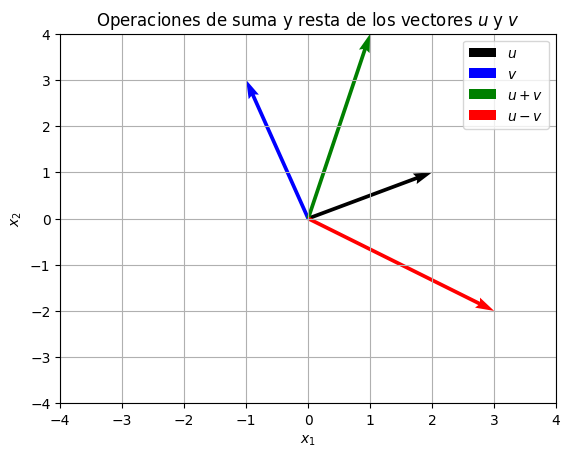

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u = np.array([2.0, 1.0])
v = np.array([-1.0, 3.0])
suma = u + v
resta = u-v

plt.title("Operaciones de suma y resta de los vectores $u$ y $v$")
plt.quiver(0, 0, *u, angles="xy", scale_units="xy", scale=1, color="black", label="$u$")
plt.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color="blue", label="$v$")
plt.quiver(0, 0, *suma, angles="xy", scale_units="xy", scale=1, color="green", label="$u+v$")
plt.quiver(0, 0, resta[0], resta[1], angles="xy", scale_units="xy", scale=1, color="red", label="$u-v$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.legend();

**Ejemplo**: multiplicación de escalar por vector

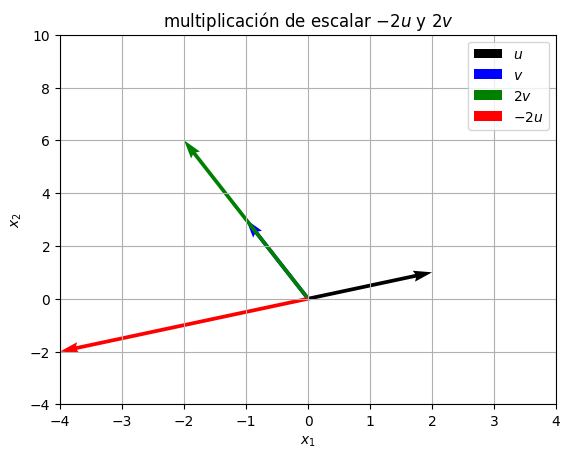

In [ ]:
# Dos vectores en R^2
u = np.array([2.0, 1.0])
v = np.array([-1.0, 3.0])

# Multiplicación por escalar
escalar_u = -2 * u
escalar_v = 2 * v

plt.title("multiplicación de escalar $-2u$ y $2v$")
plt.quiver(0, 0, *u, angles="xy", scale_units="xy", scale=1, color="black", label="$u$")
plt.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color="blue", label="$v$")
plt.quiver(0, 0, *escalar_v, angles="xy", scale_units="xy", scale=1, color="green", label="$2v$")
plt.quiver(0, 0, *escalar_u, angles="xy", scale_units="xy", scale=1, color="red", label="$-2u$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-4, 4)
plt.ylim(-4, 10)
plt.grid()
plt.legend();


## 3. Combinación lineal

Una combinación lineal de vectores $\mathbf{v}_1,\ldots,\mathbf{v}_k$ es:
$$
\mathbf{x}=\alpha_1\mathbf{v}_1+\alpha_2\mathbf{v}_2+\cdots+\alpha_k\mathbf{v}_k.
$$
Donde los escalares $\alpha_i$ determinan cuánto aporta cada vector.

### Interpretación geométrica

Si tenemos dos vectores no colineales en $\mathbb{R}^2$, todas sus combinaciones lineales pueden generar cualquier punto del plano.

Esta idea es muy importante en Deep Learning: una capa totalmente conectada calcula combinaciones lineales de las características de entrada.
$$
z_j=\sum_i W_{ji}x_i+b_j.
$$

Sin la función de activación, una secuencia de capas lineales puede reducirse a una única transformación lineal/afín. Por eso las activaciones son necesarias para construir modelos con capacidad de representar relaciones no lineales.

Nota: si tenemos una capa con una única neurona. Tendríamos la ecuación de la recta $y=mx + b$ ó  $(Wx+b)$


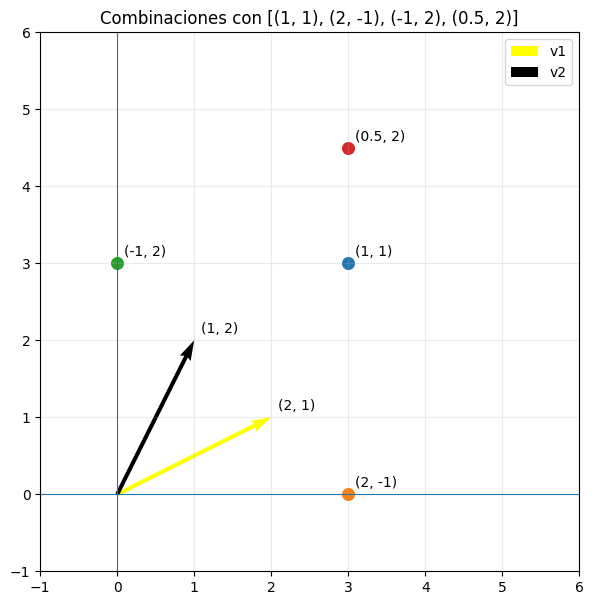

In [ ]:
v1 = np.array([2, 1])
v2 = np.array([1, 2])

# Algunas combinaciones lineales
coefs = [(1, 1), (2, -1), (-1, 2), (0.5, 2)]

fig, ax = plt.subplots(figsize=(7, 7))

for a, b in coefs:
    x = a * v1 + b * v2
    ax.scatter(x[0], x[1], s=70)
    ax.annotate(f"({a}, {b})", x, xytext=(5, 5), textcoords="offset points")

ax.quiver(0, 0, *v1, angles="xy", scale_units="xy", scale=1, color="yellow", label="v1")
ax.annotate(f"({v1[0]}, {v1[1]})", v1, xytext=(5, 5), textcoords="offset points")
ax.quiver(0, 0, *v2, angles="xy", scale_units="xy", scale=1, label="v2")
ax.annotate(f"({v2[0]}, {v2[1]})", v2, xytext=(5, 5), textcoords="offset points")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect("equal")
ax.set_title(f"Combinaciones con {coefs}")
ax.grid(alpha=0.25)
plt.legend()
plt.show()


## 4. Span e independencia lineal

### Span o espacio generado

El **span** de un conjunto de vectores es el conjunto de todas sus combinaciones lineales:
$$
\operatorname{span}(\mathbf{v}_1,\ldots,\mathbf{v}_k).
$$
### Independencia lineal

Los vectores son linealmente independientes si:
$$
\alpha_1\mathbf{v}_1+\cdots+\alpha_k\mathbf{v}_k=\mathbf{0}
$$

En otras palabras, dos vectores o más son independientes si ningún vector del grupo se puede escribir como la combinación de los demás. Si tenemos dos vectores $u$ y $v$, estos son independientes si tienen diferentes direcciónes, y no están sobre la misma línea, ni son paralelas.

## 5. Subespacios vectoriales

Un **subespacio** es un subconjunto de un espacio vectorial que también es un espacio vectorial.

Una forma práctica de reconocerlo es comprobar que se cumplan las siguientes condiciones:

- contiene al vector cero.
- es cerrado bajo suma (si sumamos dos vectores, el vector resultante debe seguir dentro del mismo subespacio).
- es cerrado bajo multiplicación escalar (si multiplicamos un escalar por un vector, el vector resultante debe seguir dentro del mismo subespacio).

### Ejemplos importantes

- una recta que pasa por el origen en $\mathbb{R}^2$;
- un plano que pasa por el origen en $\mathbb{R}^3$;
- el espacio nulo de una matriz;
- el espacio columna de una matriz.

Los subespacios ayudan a interpretar restricciones y pérdida de dimensionalidad en transformaciones.


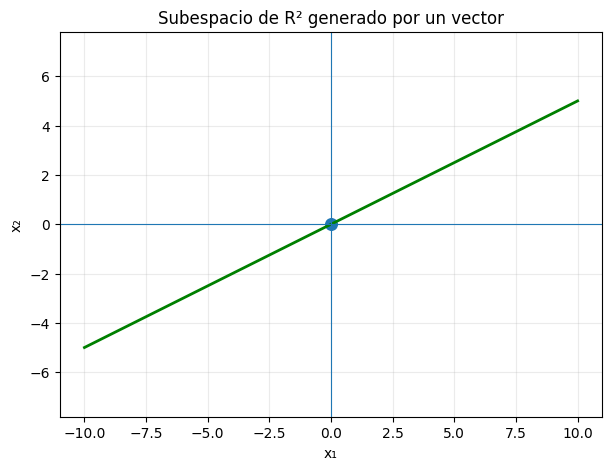

In [ ]:
# Ejemplo: un subespacio generado por una dirección
d = np.array([2.0, 1.0])
t = np.linspace(-5, 5, 100)
points = np.outer(t, d)
plt.figure(figsize=(7, 5))
plt.plot(points[:, 0], points[:, 1], linewidth=2, color="green")
plt.scatter([0], [0], s=70)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Subespacio de R² generado por un vector")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(alpha=0.25)
plt.axis("equal")
plt.show()


## 6. Transformaciones lineales

Una transformación lineal de la forma
$$
T:V\rightarrow W
$$
es lineal si cumple, para todos los vectores $\mathbf{u},\mathbf{v}$ y escalares $\alpha\$ las dos reglas básicas:

#### Aditividad

$$
T(\mathbf{u}+\mathbf{v})=T(\mathbf{u})+T(\mathbf{v})
$$

#### Homogeneidad

$$
T(\alpha\mathbf{u})=\alpha T(\mathbf{u}).
$$

Toda transformación lineal entre espacios de dimensión finita puede representarse mediante una matriz:

$$
T(\mathbf{x})=A\mathbf{x}.
$$

### Interpretación

La matriz no es solamente una tabla de números: representa una **regla de transformación del espacio**.

Puede:

- rotar;
- escalar;
- reflejar;
- proyectar;
- deformar;
- combinar estas operaciones.

En una red neuronal, una capa lineal utiliza una matriz de pesos **$A$** para transformar la representación de entrada.


**Ejemplo**: Transformación lineal, rotación de 45°:

Matriz A:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

x = [2. 0.]
T(x) = Ax = [1.41421356 1.41421356]


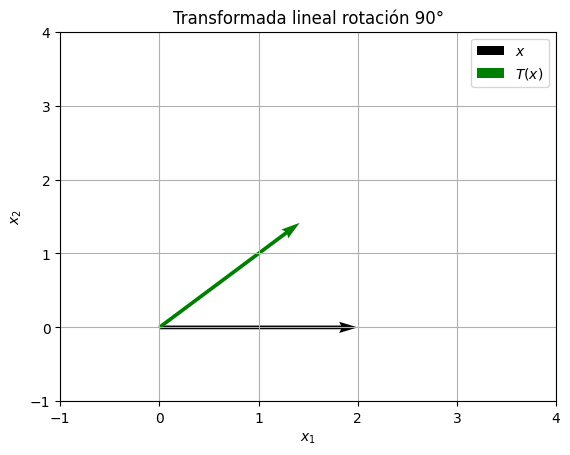

In [ ]:
theta = np.deg2rad(45)
A = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

x = np.array([2.0, 0])
y = A @ x

print("Matriz A:")
print(A)
print("\nx =", x)
print("T(x) = Ax =", y)

# Dos vectores en R^2
u = np.array([2.0, 1.0])
v = np.array([-1.0, 3.0])

# Multiplicación por escalar
escalar_u = -2 * u
escalar_v = 2 * v

plt.title("Transformada lineal rotación 90°")
plt.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1, color="black", label="$x$")
plt.quiver(0, 0, *y, angles="xy", scale_units="xy", scale=1, color="green", label="$T(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.grid()
plt.legend();


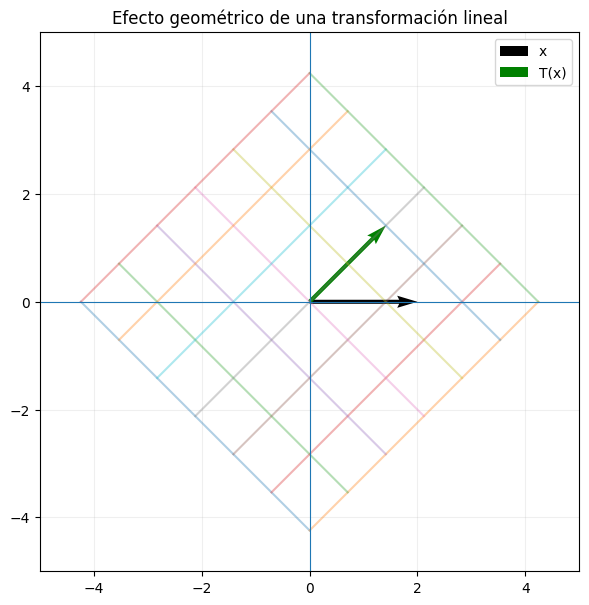

In [ ]:
# Visualización de una transformación lineal sobre una cuadrícula

grid = np.arange(-3, 4)
fig, ax = plt.subplots(figsize=(7, 7))

# Líneas verticales y horizontales originales
for i in grid:
    pts = np.array([[i, -3], [i, 3]], dtype=float)
    transformed = pts @ A.T
    ax.plot(transformed[:, 0], transformed[:, 1], alpha=0.35)

    pts = np.array([[-3, i], [3, i]], dtype=float)
    transformed = pts @ A.T
    ax.plot(transformed[:, 0], transformed[:, 1], alpha=0.35)


ax.quiver(0, 0, x[0], x[1], angles="xy", scale_units="xy", scale=1, label="x")
ax.quiver(0, 0, y[0], y[1], angles="xy", scale_units="xy", scale=1, label="T(x)", color="green")

plt.xlim(-5, 5)
plt.ylim(-5, 5)
ax.set_aspect("equal")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title("Efecto geométrico de una transformación lineal")
ax.grid(alpha=0.2)
plt.legend()
plt.show()


## 7. Transformación en una capa densa (o neurona)

Una capa neuronal normalmente tiene la forma:

$$
\mathbf{z}=W\mathbf{x}+\mathbf{b}.
$$

Donde:
- La parte $W\mathbf{x}$ es una transformación lineal, donde $W$ son los pesos que se ajustarán en el entrenamiento, y $x$ es la entrada de nuestro modelo o la salida de la capa anterior

- $\mathbf{b}$ representa el sesgo.


<center>


Después se aplica una función de activación (que profundizaremos en la segunda semana):

$$
\mathbf{y}=\sigma(W\mathbf{x}+\mathbf{b}).
$$

Este detalle es fundamental: si apilamos únicamente transformaciones lineales, su composición sigue siendo lineal. La no linealidad de $\sigma$ permite que la red aprenda fronteras y representaciones mucho más complejas.

In [ ]:
# Composición de dos transformaciones lineales
W1 = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

W2 = np.array([
    [1.0, 1.0],
    [0.0, 1.0]
])

x = np.array([2.0, 3.0])

salida_dos_capas = W2 @ (W1 @ x)
salida_compuesta = (W2 @ W1) @ x

print("W2(W1x) =", salida_dos_capas)
print("(W2W1)x  =", salida_compuesta)
print("¿Son iguales?", np.allclose(salida_dos_capas, salida_compuesta))


W2(W1x) = [5.5 1.5]
(W2W1)x  = [5.5 1.5]
¿Son iguales? True


## 8. Subespacios vectoriales: Núcleo (kernel) e imagen

Dada una transformación $T(\mathbf{x})=A\mathbf{x}$:

### Núcleo

El núcleo o espacio nulo es:
$$
\ker(A)=\{\mathbf{x}:A\mathbf{x}=\mathbf{0}\}.
$$

Contiene las direcciones que la transformación **elimina**.

### Imagen

La imagen es el conjunto de salidas posibles:

$$
\operatorname{Im}(A)=\{A\mathbf{x}:\mathbf{x}\in V\}.
$$

### Conexión con Deep Learning

Cuando una transformación reduce dimensionalidad, algunas direcciones pueden quedar colapsadas. Esto ayuda a interpretar por qué una transformación puede perder información.

El rango de una matriz nos indica la dimensión efectiva de su imagen.


**Ejemplo:** transformación que proyecta $\mathbb{R}^2$ sobre el eje x

In [ ]:
P = np.array([
    [1.0, 0.0],
    [0.0, 0.0]
])

points = np.array([
    [1, 2],
    [2, -1],
    [-1, 3],
    [3, 4]
], dtype=float)

projected = points @ P.T

print("Puntos originales:")
print(points)

print("\nPuntos transformados:")
print(projected)

print("\nRango de P:", np.linalg.matrix_rank(P))


Puntos originales:
[[ 1.  2.]
 [ 2. -1.]
 [-1.  3.]
 [ 3.  4.]]

Puntos transformados:
[[ 1.  0.]
 [ 2.  0.]
 [-1.  0.]
 [ 3.  0.]]

Rango de P: 1


## 9. Producto punto, normas y similitud

El **producto punto** basícamente nos indica si dos vectores apuntan en la misma dirección y que tan grandes son:

$$
\mathbf{u}^\top\mathbf{v}=\sum_i u_i v_i
$$

- si $\mathbf{u}^\top\mathbf{v}$ > 0 : Apuntan en direcciones similares  
- si $\mathbf{u}^\top\mathbf{v}$ = 0 : Son perpendiculares  
- si $\mathbf{u}^\top\mathbf{v}$ < 0 : Apuntan en direcciones opuestas  

Por otro lado, la **norma** nos permite medir la longitud o tamaño de un vector desde el origen. La medida mas cómun o utilizada es la Norma Euclidiana:
$$
L_2 = \|\mathbf{u}\| = \sqrt{u\cdot u} = \sqrt{\sum{u_{i}^{2}}}
$$

De la cual podemos inferir la **similitud** del cosemo, la cual nos permite inferir la orientación entre dos vectores, sin tener en cuenta el tamaño o magnitud:

$$
\cos(\theta)=
\frac{\mathbf{u}^\top\mathbf{v}}
{\|\mathbf{u}\|\|\mathbf{v}\|}.
$$

**Nota**: Este concepto es útil cuando el **ángulo**, más que la magnitud, representa mejor la similitud entre ejemplos. Esto aparece en aplicaciones como embeddings de texto y representaciones de alta dimensión.


**Ejemplo**: Similitud entre vectores

cos(u, v) = 0.9999999999999998
cos(u, w) = 0.14142135623730948
cos(u, -v) = -0.9999999999999998


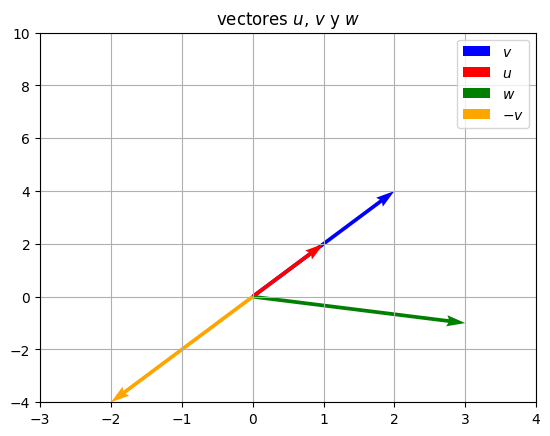

In [ ]:
u = np.array([1.0, 2.0])
v = np.array([2.0, 4.0])  # misma dirección, distinta magnitud
v_neg = -1*v
w = np.array([3.0, -1.0])

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("cos(u, v) =", cosine_similarity(u, v))
print("cos(u, w) =", cosine_similarity(u, w))
print("cos(u, -v) =", cosine_similarity(u, -1*v))

plt.title("vectores $u$, $v$ y $w$")
plt.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color="blue", label="$v$")
plt.quiver(0, 0, *u, angles="xy", scale_units="xy", scale=1, color="red", label="$u$")
plt.quiver(0, 0, *w, angles="xy", scale_units="xy", scale=1, color="green", label="$w$")
plt.quiver(0, 0, *v_neg, angles="xy", scale_units="xy", scale=1, color="orange", label="$-v$")
plt.xlim(-3, 4)
plt.ylim(-4, 10)
plt.grid()
plt.legend();


## 10. Hiperplanos y clasificación

Un hiperplano en $\mathbb{R}^d$ puede expresarse como:

$$
\mathbf{w}^\top\mathbf{x}+b=0.
$$

donde:

- $\mathbf{x}$ es el vector de entrada.  
- $\mathbf{w}$ es el vector de pesos.  
- $b$ es el sesgo (bias).  
- $\mathbf{w}$ es perpendicular al plano

Esto permite dividir el espacio en dos regiones. Esta es una conexión directa con clasificadores lineales y con la última capa lineal de muchas redes neuronales.

Dependiendo del número de dimensiones de $\mathbf{x}$:

- $x\in\mathbb{R}^1$ ->	Punto
- $x\in\mathbb{R}^2$ -> Recta
- $x\in\mathbb{R}^3$ -> Plano
- $x\in\mathbb{R}^n$ -> Hiperplano

Por eso se habla de hiperplano como término general.


### Ejemplo

Consideremos:

$$
2x_1+x_2-4=0.
$$

Los puntos para los que la expresión es positiva quedan en un lado y los negativos en el otro.


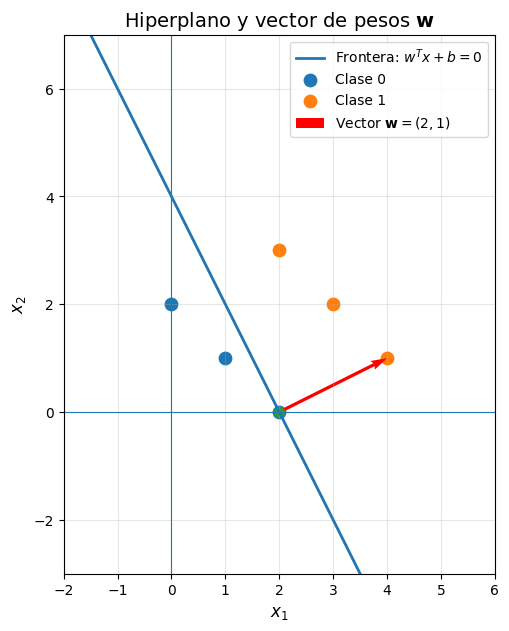

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pesos y bias
w = np.array([2.0, 1.0])
b = -4
# Ecuación: 2x1 + x2 - 4 = 0
x1 = np.linspace(-2, 5, 200)
x2 = -(w[0] * x1 + b) / w[1]

# Puntos de las clases
class_0 = np.array([
    [1, 1],
    [0, 2],
    [2, 0]
])
class_1 = np.array([
    [3, 2],
    [4, 1],
    [2, 3]
])

plt.figure(figsize=(9, 7))
# Hiperplano / frontera de decisión
plt.plot(x1, x2, linewidth=2, label=r'Frontera: $w^Tx+b=0$')

# Puntos
plt.scatter(class_0[:, 0], class_0[:, 1], s=80, label='Clase 0')

plt.scatter(class_1[:, 0], class_1[:, 1], s=80, label='Clase 1')

# --------------------------------------------------
# Vector w
# --------------------------------------------------

# Punto sobre la frontera
punto_inicio = np.array([2.0, 0.0])

# Dibujamos w desde ese punto
plt.quiver(punto_inicio[0], punto_inicio[1], w[0], w[1], angles='xy',
           scale_units='xy', scale=1, linewidth=2,color='red', label=r'Vector $\mathbf{w}=(2,1)$')

# Punto de origen del vector
plt.scatter(punto_inicio[0], punto_inicio[1], s=50)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title(r'Hiperplano y vector de pesos $\mathbf{w}$', fontsize=14
)
plt.xlim(-2, 6)
plt.ylim(-3, 7)

plt.grid(alpha=0.3)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

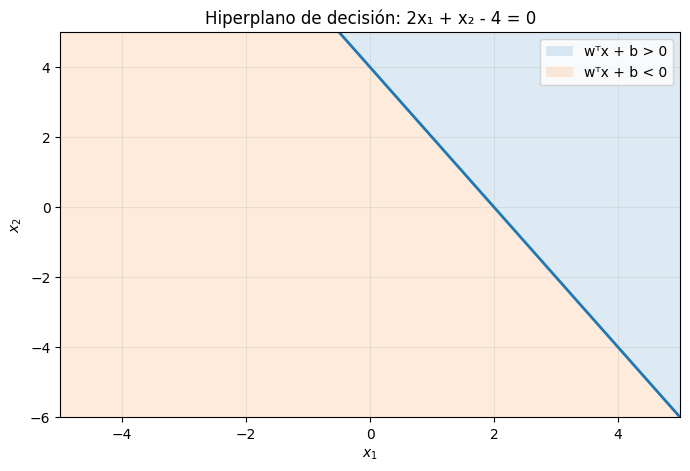

In [ ]:
# Visualización de un hiperplano en R² (una recta)

x1 = np.linspace(-5, 5, 200)
x2 = 4 - 2*x1

plt.figure(figsize=(8, 5))
plt.plot(x1, x2, linewidth=2)
plt.fill_between(x1, x2, 6, alpha=0.15, label="wᵀx + b > 0")
plt.fill_between(x1, x2, -6, alpha=0.15, label="wᵀx + b < 0")

plt.xlim(-5, 5)
plt.ylim(-6, 5)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Hiperplano de decisión: 2x₁ + x₂ - 4 = 0")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 11. Valores propios y vectores propios

Una matriz puede transformar cualquier vector de muchas maneras. Sin embargo, existen ciertas direcciones especiales que, al aplicar la transformación, no cambian de dirección. Esas son las direcciones propias o autovectores. El autovalor nos dice cuánto se amplifica o se reduce esa dirección. En Deep Learning, esta idea nos ayuda a analizar cómo las transformaciones de las capas afectan las representaciones y, especialmente, cómo pueden amplificar o disminuir la información y los gradientes durante el entrenamiento.

Para una matriz cuadrada $A$, un vector propio $\mathbf{v}\neq0$ satisface:

$$
A\mathbf{v}=\lambda\mathbf{v}.
$$

Aquí:

- $\mathbf{v}$ es un **vector propio**;
- $\lambda$ es su **valor propio**.

La interpretación geométrica es poderosa: una transformación puede cambiar la longitud de un vector propio —y eventualmente su sentido— sin cambiar su dirección.

Los valores propios y vectores propios permiten estudiar la estructura de una transformación, analizar direcciones principales y comprender fenómenos de escalamiento.

En Deep Learning, estos conceptos ayudan a construir intuición sobre estabilidad, direcciones dominantes y transformaciones de matrices.

**¿Qué creen que ocurre si después de 50 capas multiplicamos repetidamente por transformaciones que reducen ciertas direcciones a la mitad?**

$$
0.5^{50}≈8.88×10^{−16}
$$

Ocurre algo denominado ***vanishing gradients*** lo cual hace que el cambio en la disminución del error en el entrenamiendo tienda a ser nulo.

In [ ]:
# Ejemplo de autovalores y autovectores
A = np.array([
    [3.0, 1.0],
    [0.0, 2.0]
])
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matriz A:")
print(A)
print("\nValores Propios:")
print(eigenvalues)
print("\nVectores Propios (columnas):")
print(eigenvectors)

# Verificación A v = lambda v
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    print(f"\nVector Propio {i+1}:")
    print("Av      =", A @ vec)
    print("lambda*v =", lam * vec)


Matriz A:
[[3. 1.]
 [0. 2.]]

Valores Propios:
[3. 2.]

Vectores Propios (columnas):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]

Vector Propio 1:
Av      = [3. 0.]
lambda*v = [3. 0.]

Vector Propio 2:
Av      = [-1.41421356  1.41421356]
lambda*v = [-1.41421356  1.41421356]


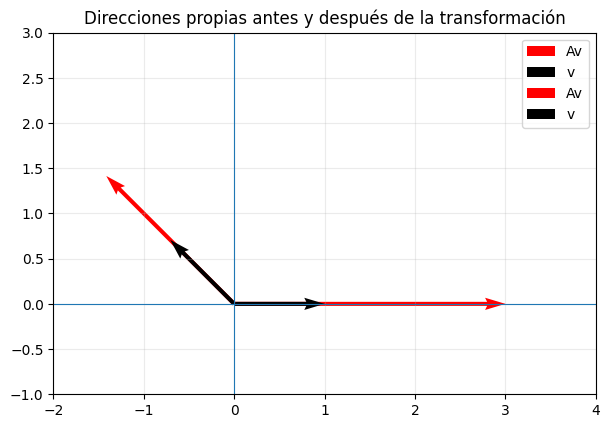

In [ ]:
# Visualización del efecto de A sobre los autovectores

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(len(eigenvalues)):
    vec = eigenvectors[:, i]
    vec = vec / np.linalg.norm(vec) #dividimos por la norma para tener el vector de magnitud 1

    transformed = A @ vec
    ax.quiver(0, 0, transformed[0], transformed[1],
              angles="xy", scale_units="xy", scale=1, color="red", label="Av")
    ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy", scale=1, label="v")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlim(-2, 4)
ax.set_ylim(-1, 3)
ax.set_aspect("equal")
ax.set_title("Direcciones propias antes y después de la transformación")
ax.grid(alpha=0.25)
plt.legend()
plt.show()


## 12. De los conceptos matemáticos a una capa de Deep Learning

Podemos reunir las ideas anteriores en una operación muy sencilla:

$$
\mathbf{z}=W\mathbf{x}+\mathbf{b}.
$$

Si:

- $\mathbf{x}\in\mathbb{R}^{d}$
- $W\in\mathbb{R}^{m\times d}$
- $\mathbf{b}\in\mathbb{R}^{m}$

entonces:

$$
\mathbf{z}\in\mathbb{R}^{m}.
$$

La capa transforma una representación de dimensión \(d\) en otra de dimensión \(m\).

Por ejemplo:

$$
\mathbb{R}^{4}\rightarrow\mathbb{R}^{3}.
$$

La siguiente celda reproduce el cálculo usando únicamente NumPy.


In [ ]:
# Una capa densa sencilla implementada con NumPy

rng = np.random.default_rng(42)

x = np.array([0.5, 1.2, -0.7, 2.0])    # R^4
W = rng.normal(size=(3, 4))             # 3 neuronas x 4 entradas
b = rng.normal(size=3)                  # sesgo para cada neurona

z = W @ x + b

print("Forma de x:", x.shape)
print("Forma de W:", W.shape)
print("Forma de b:", b.shape)
print("Forma de z:", z.shape)
print("z =", z)


Forma de x: (4,)
Forma de W: (3, 4)
Forma de b: (3,)
Forma de z: (3,)
z = [ 0.32622191 -2.13286526  0.37546134]


## 13. ¿Dónde aparece la no linealidad?

Si usamos dos capas sin activación:

$$
\mathbf{z}=W_2(W_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2,
$$

podemos reagrupar:

$$
\mathbf{z}
=(W_2W_1)\mathbf{x}+(W_2\mathbf{b}_1+\mathbf{b}_2).
$$

Es decir, la composición de capas afines sigue siendo una transformación afín.

Por eso utilizamos funciones de activación:

$$
\mathbf{h}=\sigma(W_1\mathbf{x}+\mathbf{b}_1)
$$

y posteriormente:

$$
\mathbf{y}=W_2\mathbf{h}+\mathbf{b}_2.
$$

La función $\sigma$ rompe la linealidad global y permite que una red profunda represente relaciones complejas.

## Referencia principal

Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. *Dive into Deep Learning*. Sección **Geometry and Linear Algebraic Operations**.

https://d2l.ai/chapter_appendix-mathematics-for-deep-learning/geometry-linear-algebraic-ops.html